# Linear regression, part 1: fitting a line

We fit a line, and then a plane, to the students dataset by minimizing the squared error.

1. the data and a first look at it
2. variance and covariance, the two summaries the closed form needs
3. the closed form for one feature, and its residuals
4. $R^2$: how much of the variation the model explains
5. multivariate regression with the normal equation

Part 2 takes the fitted model and asks whether it can be trusted.

In [1]:
import matplotlib.pyplot as plt

## Setup

Imports and plotting configuration for the whole notebook.

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import scipy.stats as stats
from scipy import stats

## The students dataset

The 16 original students, then the augmentation: 10 noisy copies per student (Gaussian noise with standard deviation 0.2, seed 42, clipped to the grade range [2, 6]) give the 160-sample dataset used throughout the course.

In [3]:
# Initial data
data = {
    'Quizzes': [5.3, 5.5, 5.5, 5.0, 2.5, 3.0, 3.0, 3.1, 3.5, 3.5, 3.7, 4.0, 4.0, 4.0, 4.0, 5.7],
    'Labs': [5.3, 5.9, 5.29, 4.35, 5.5, 5.0, 4.0, 3.1, 4.5, 5.62, 5.0, 3.0, 4.0, 5.75, 4.44, 5.9],
    'Final': [4.818, 5.773, 4.464, 5.069, 4.164, 4.091, 3.727, 3.909, 3.518, 4.897, 5.209, 3.0, 3.091, 5.818, 4.069, 5.77]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Augmenting data by replicating and adding noise
np.random.seed(42)
augmented = []
for i in range(len(df)):
    row = df.iloc[i]
    for _ in range(10):  # Create 10 variations of each record
        noise = np.random.normal(0, 0.2, 3)  # Add Gaussian noise with mean=0 and std=0.2
        new_row = row + noise
        # Ensure values are within boundaries (grades must be between 2 and 6)
        new_row = new_row.clip(2, 6)
        augmented.append(new_row)

# Create augmented DataFrame
df_aug = pd.DataFrame(augmented, columns=df.columns)

## Data exploration

The distributions of the three grades. Looking at the data comes before any model.

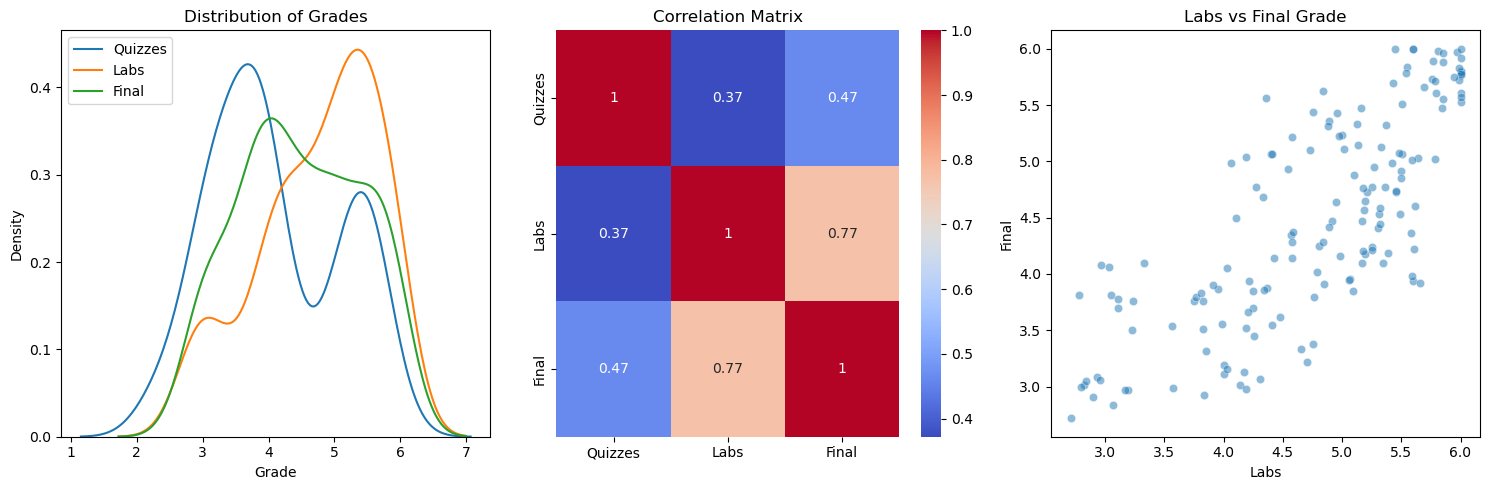

In [4]:
# Data Exploration and Visualization
plt.figure(figsize=(15, 5))

# Distribution of grades
plt.subplot(131)
sns.kdeplot(data=df_aug, x='Quizzes', label='Quizzes')
sns.kdeplot(data=df_aug, x='Labs', label='Labs')
sns.kdeplot(data=df_aug, x='Final', label='Final')
plt.title('Distribution of Grades')
plt.xlabel('Grade')
plt.ylabel('Density')
plt.legend()


# Correlation heatmap
plt.subplot(132)
sns.heatmap(df_aug.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')

# Pairplot
plt.subplot(133)
sns.scatterplot(data=df_aug, x='Labs', y='Final', alpha=0.5)
plt.title('Labs vs Final Grade')
plt.tight_layout()
plt.show()

The same distributions as histograms with kernel density estimates, one panel per feature.

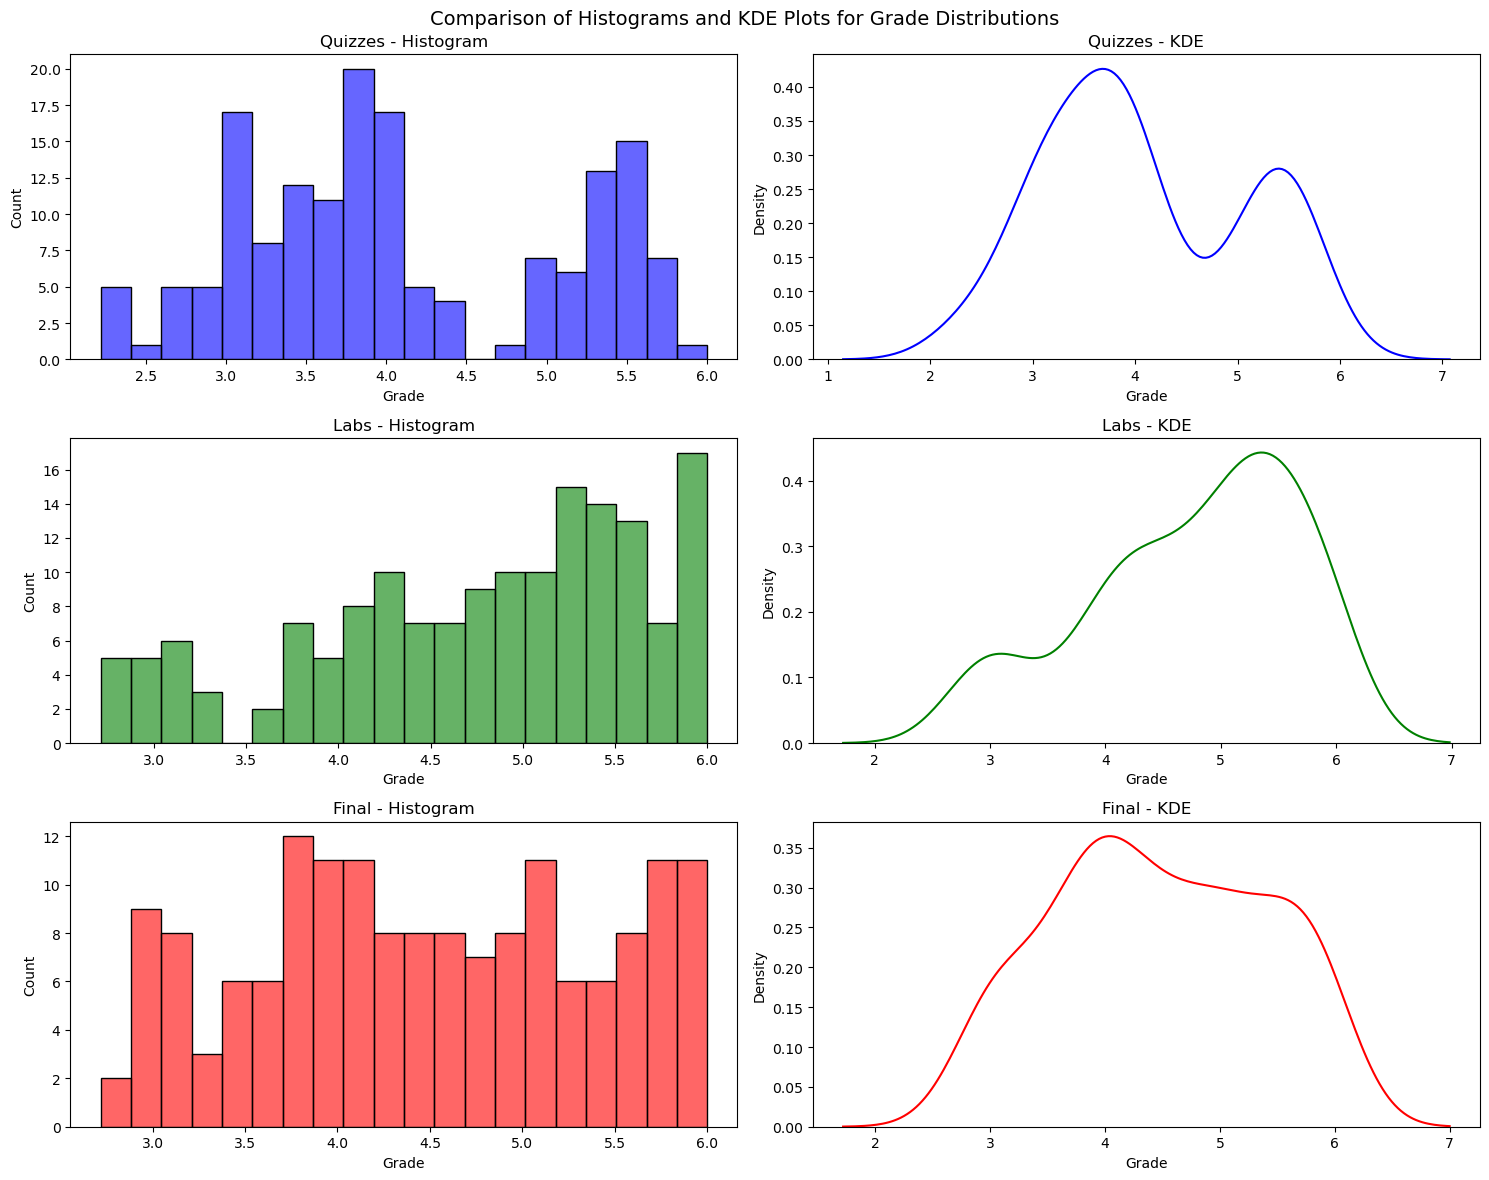


Summary Statistics:
       Quizzes     Labs    Final
count  160.000  160.000  160.000
mean     4.091    4.762    4.479
std      0.984    0.905    0.919
min      2.220    2.710    2.719
25%      3.336    4.190    3.809
50%      3.861    4.952    4.432
75%      5.090    5.492    5.229
max      6.000    6.000    6.000


In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
plt.suptitle('Comparison of Histograms and KDE Plots for Grade Distributions', fontsize=14)


colors = {'Quizzes': 'blue', 'Labs': 'green', 'Final': 'red'}

for idx, column in enumerate(df_aug.columns):
    # Histogram
    sns.histplot(data=df_aug[column], bins=20, ax=axes[idx, 0], color=colors[column], alpha=0.6)
    axes[idx, 0].set_title(f'{column} - Histogram')
    axes[idx, 0].set_xlabel('Grade')
    axes[idx, 0].set_ylabel('Count')
    
    # KDE
    sns.kdeplot(data=df_aug[column], ax=axes[idx, 1], color=colors[column])
    axes[idx, 1].set_title(f'{column} - KDE')
    axes[idx, 1].set_xlabel('Grade')
    axes[idx, 1].set_ylabel('Density')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(df_aug.describe().round(3))

## Variance and covariance

Before the closed form, two summary statistics. The **variance** measures how far one feature spreads around its mean, and the **covariance** measures whether two features move together:

$$\tilde{s}_x^2 = \frac{1}{M}\sum_{m=1}^{M}(x^{(m)} - \mu_x)^2, \qquad \tilde{s}_{xy} = \frac{1}{M}\sum_{m=1}^{M}(x^{(m)} - \mu_x)(y^{(m)} - \mu_y)$$

Each point contributes the product of its two deviations from the means: positive when both are above or both below, negative when they disagree. The plot below splits the data at the two means and colors the points by the sign of that product.

In [ ]:
# variance and covariance, computed by hand and with numpy
x = np.array(df_aug['Labs'])
y = np.array(df_aug['Final'])
mu_x, mu_y = x.mean(), y.mean()

var_x = np.mean((x - mu_x) ** 2)
cov_xy = np.mean((x - mu_x) * (y - mu_y))
print(f"mean Labs  = {mu_x:.2f},  mean Final = {mu_y:.2f}")
print(f"variance of Labs        = {var_x:.3f}")
print(f"covariance(Labs, Final) = {cov_xy:.3f}")
print(f"slope  cov / var        = {cov_xy / var_x:.3f}")

# the sign of each point's contribution
contribution = (x - mu_x) * (y - mu_y)

plt.figure(figsize=(6, 5))
plt.axhspan(mu_y, y.max() + 0.3, xmin=0.5, color='tab:blue', alpha=0.07)
plt.axhspan(y.min() - 0.3, mu_y, xmax=0.5, color='tab:blue', alpha=0.07)
plt.scatter(x[contribution > 0], y[contribution > 0], s=18, color='tab:blue', label='product > 0')
plt.scatter(x[contribution <= 0], y[contribution <= 0], s=18, color='tab:red', label='product < 0')
plt.axvline(mu_x, color='k', lw=1.2)
plt.axhline(mu_y, color='k', lw=1.2)
plt.xlabel('Labs'); plt.ylabel('Final')
plt.title(f'covariance = {cov_xy:.2f} (blue quadrants dominate)')
plt.legend()
plt.show()

### The covariance matrix

Collecting the variances and covariances of all features gives a symmetric matrix: variances on the diagonal, covariances off it. `np.cov` uses the $1/(M-1)$ convention by default, so we pass `bias=True` to match the formula above.

In [ ]:
features = ['Quizzes', 'Labs', 'Final']
Sigma = np.cov(df_aug[features].values.T, bias=True)
print("covariance matrix")
print(pd.DataFrame(Sigma, index=features, columns=features).round(2))

print("\ncorrelation matrix (covariance divided by both standard deviations)")
print(pd.DataFrame(np.corrcoef(df_aug[features].values.T), index=features, columns=features).round(2))

# the slope of the univariate fit is one cell of the covariance matrix, divided by a variance
print(f"\nslope from the matrix: {Sigma[1, 2] / Sigma[1, 1]:.3f}")

**Check:** the slope printed above should equal `optimal_theta1` from the closed-form cell below, because minimizing the squared error gives exactly $\theta_1 = \tilde{s}_{xy} / \tilde{s}_x^2$. Covariance is measured in the units of both features, so its size is not comparable across datasets; the correlation matrix rescales it to $[-1, 1]$.

Now we will implement the closed form (analytical version) of linear regression.


**Implementation of the normal equation for univariate linear regression**

Optimal parameters:
θ₀ (intercept) = 0.754
θ₁ (slope) = 0.782
MSE = 0.342


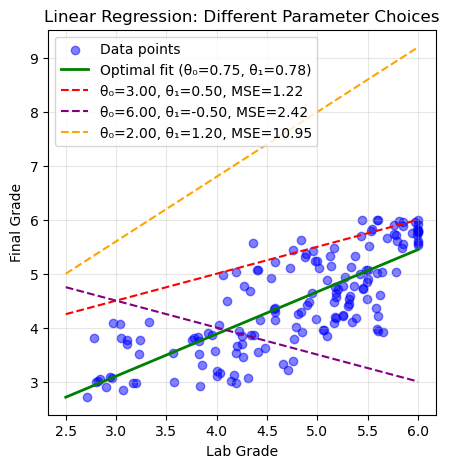

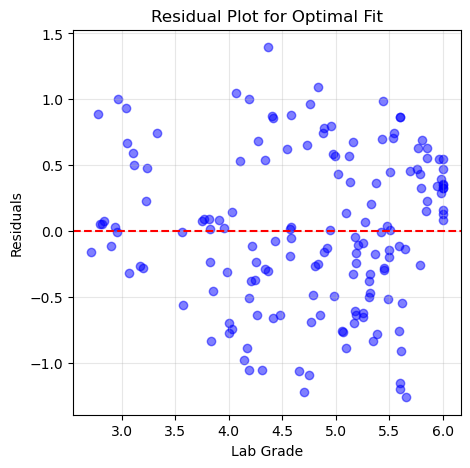

R² Score: 0.593


In [13]:
# Convert to numpy arrays
X = np.array(df_aug['Labs'])
y = np.array(df_aug['Final'])

# Closed form solution using the normal equation
X_with_ones = np.column_stack([np.ones_like(X), X])
optimal_params = np.linalg.inv(X_with_ones.T @ X_with_ones) @ X_with_ones.T @ y
optimal_theta0, optimal_theta1 = optimal_params

# Function to compute MSE (univariate case)
def compute_mse(theta0, theta1, X, y):
    y_pred = theta0 + theta1 * X
    return np.mean((y - y_pred) ** 2)

# plotting
plt.figure(figsize=(5, 5))

# Scatter plot of original data
plt.scatter(X, y, color='blue', alpha=0.5, label='Data points')

# Plot range for regression lines
x_range = np.array([2.5, 6.0])

# optimal line
y_optimal = optimal_theta0 + optimal_theta1 * x_range
plt.plot(x_range, y_optimal, 'g-', linewidth=2, 
         label=f'Optimal fit (θ₀={optimal_theta0:.2f}, θ₁={optimal_theta1:.2f})')

# bad fits
bad_fits = [
    (3, 0.5, 'red'),    # Too flat
    (6, -0.5, 'purple'),  # Negative slope
    (2, 1.2, 'orange'),   # Too steep
]

for theta0, theta1, color in bad_fits:
    y_bad = theta0 + theta1 * x_range
    mse = compute_mse(theta0, theta1, X, y)
    plt.plot(x_range, y_bad, color=color, linestyle='--',
             label=f'θ₀={theta0:.2f}, θ₁={theta1:.2f}, MSE={mse:.2f}')

# Customize plot
plt.xlabel('Lab Grade')
plt.ylabel('Final Grade')
plt.title('Linear Regression: Different Parameter Choices')
plt.grid(True, alpha=0.3)
plt.legend()

# optimal parameters and MSE
optimal_mse = compute_mse(optimal_theta0, optimal_theta1, X, y)
print(f"Optimal parameters:")
print(f"θ₀ (intercept) = {optimal_theta0:.3f}")
print(f"θ₁ (slope) = {optimal_theta1:.3f}")
print(f"MSE = {optimal_mse:.3f}")

plt.show()

# residual plot for the optimal fit
plt.figure(figsize=(5, 5))

# Compute residuals for optimal fit
y_pred_optimal = optimal_theta0 + optimal_theta1 * X
residuals = y - y_pred_optimal

plt.scatter(X, residuals, color='blue', alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Lab Grade')
plt.ylabel('Residuals')
plt.title('Residual Plot for Optimal Fit')
plt.grid(True, alpha=0.3)

plt.show()



# Calculate R² (only for Labs vs Quizzes, so univariate)
r2 = r2_score(y, y_pred_optimal)


print(f"R² Score: {r2:.3f}")

**Residuals analysis**

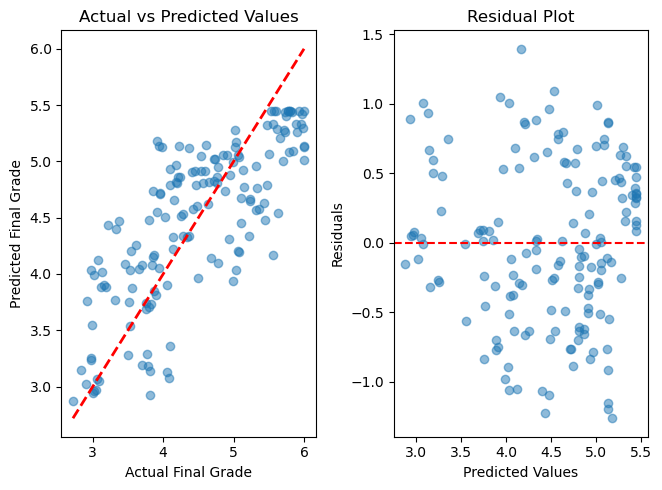

R² Score: 0.593


In [15]:
# Calculate residuals
residuals = y - y_pred_optimal


# Plotting
plt.figure(figsize=(10, 5))

# Actual vs Predicted
plt.subplot(131)
plt.scatter(y, y_pred_optimal, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Final Grade')
plt.ylabel('Predicted Final Grade')
plt.title('Actual vs Predicted Values')

# Residual Plot
plt.subplot(132)
plt.scatter(y_pred_optimal, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# QQ Plot

#plt.subplot(133)
#stats.probplot(residuals, dist="norm", plot=plt)
#plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()
print(f"R² Score: {r2_score(y, y_pred_optimal):.3f}")


Numerical summary of the fit: $R^2$ and the residual statistics. The residual mean sits at zero by construction of the least-squares solution.

In [17]:
# Statistics

print(f"R² Score: {r2_score(y, y_pred_optimal):.3f}")


print("\nResidual Statistics:")
print(f"Mean of Residuals: {np.mean(residuals):.3e}")  # Should be very close to 0
print(f"Standard Deviation of Residuals: {np.std(residuals):.3f}")
print(f"Range of Residuals: [{np.min(residuals):.3f}, {np.max(residuals):.3f}]")




# Q-Q plot
#plt.subplot(132)
#stats.probplot(residuals, dist="norm", plot=plt)
#plt.title('Q-Q Plot of Residuals')

# Residual histogram
#plt.subplot(133)
#plt.hist(residuals, bins=20, edgecolor='black')
#plt.title('Distribution of Residuals')
#plt.xlabel('Residual Value')
#plt.ylabel('Count')
#plt.tight_layout()
#plt.show()

R² Score: 0.593

Residual Statistics:
Mean of Residuals: 9.481e-15
Standard Deviation of Residuals: 0.584
Range of Residuals: [-1.262, 1.396]


**Multivariate regression**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Initial data
data = {
    'Quizzes': [5.3, 5.5, 5.5, 5.0, 2.5, 3.0, 3.0, 3.1, 3.5, 3.5, 3.7, 4.0, 4.0, 4.0, 4.0, 5.7],
    'Labs': [5.3, 5.9, 5.29, 4.35, 5.5, 5.0, 4.0, 3.1, 4.5, 5.62, 5.0, 3.0, 4.0, 5.75, 4.44, 5.9],
    'Final': [4.818, 5.773, 4.464, 5.069, 4.164, 4.091, 3.727, 3.909, 3.518, 4.897, 5.209, 3.0, 3.091, 5.818, 4.069, 5.77]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Augment data
np.random.seed(42)
augmented = []
for i in range(len(df)):
    row = df.iloc[i]
    for _ in range(10):
        noise = np.random.normal(0, 0.2, 3)
        new_row = row + noise
        new_row = new_row.clip(2, 6)
        augmented.append(new_row)

df_aug = pd.DataFrame(augmented, columns=df.columns)

# Compute optimal parameters using closed form solution
X = df_aug[['Quizzes', 'Labs']].values
y = df_aug['Final'].values
X_with_ones = np.column_stack([np.ones(len(X)), X])
optimal_params = np.linalg.inv(X_with_ones.T @ X_with_ones) @ X_with_ones.T @ y
theta_opt = optimal_params

# Function to compute predicted values for a grid
def compute_plane(theta0, theta1, theta2, xx, yy):
    return theta0 + theta1 * xx + theta2 * yy

### Visualizing the fitted plane

A mesh grid over the two features and the predicted value at every grid point: with two inputs, the linear hypothesis is a plane.

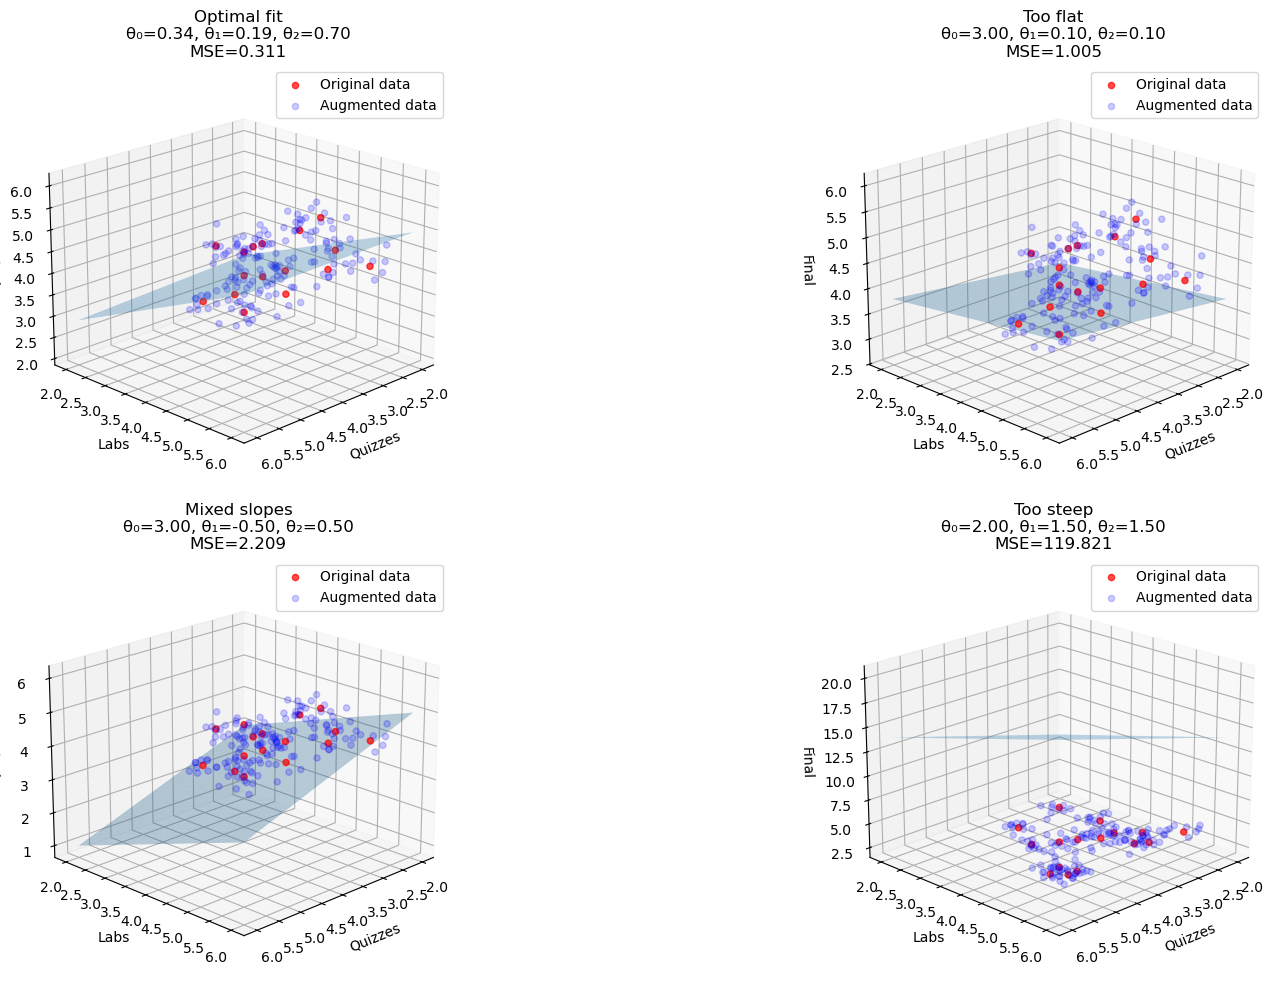


Optimal parameters:
θ₀ (intercept) = 0.335
θ₁ (Quizzes coefficient) = 0.193
θ₂ (Labs coefficient) = 0.704


In [19]:
# Create meshgrid for plotting
x_range = np.linspace(2, 6, 30)
y_range = np.linspace(2, 6, 30)
xx, yy = np.meshgrid(x_range, y_range)

# Create figure with subplots
fig = plt.figure(figsize=(20, 10))

# List of parameter sets to visualize
parameter_sets = [    (theta_opt, 'Optimal fit'),
    ([3, 0.1, 0.1], 'Too flat'),
    ([3, -0.5, 0.5], 'Mixed slopes'),
    ([2, 1.5, 1.5], 'Too steep')
]

# Plot each parameter set
for idx, (params, title) in enumerate(parameter_sets, 1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    
    # Plot the data points
    ax.scatter(df['Quizzes'], df['Labs'], df['Final'], 
              color='red', alpha=0.7, label='Original data')
    ax.scatter(df_aug['Quizzes'], df_aug['Labs'], df_aug['Final'], 
              color='blue', alpha=0.2, label='Augmented data')
    
    # Plot the regression plane
    zz = compute_plane(params[0], params[1], params[2], xx, yy)
    surf = ax.plot_surface(xx, yy, zz, alpha=0.3)
    
    # Calculate MSE
    y_pred = params[0] + params[1] * X[:, 0] + params[2] * X[:, 1]
    mse = np.mean((y - y_pred) ** 2)
    
    ax.set_xlabel('Quizzes')
    ax.set_ylabel('Labs')
    ax.set_zlabel('Final')
    ax.set_title(f'{title}\nθ₀={params[0]:.2f}, θ₁={params[1]:.2f}, θ₂={params[2]:.2f}\nMSE={mse:.3f}')
    ax.legend()
    
    ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# Print optimal parameters
print("\nOptimal parameters:")
print(f"θ₀ (intercept) = {theta_opt[0]:.3f}")
print(f"θ₁ (Quizzes coefficient) = {theta_opt[1]:.3f}")
print(f"θ₂ (Labs coefficient) = {theta_opt[2]:.3f}")

**Analysis of the multivariate results**

The coefficients say how much the predicted grade changes per point of each feature, holding the other fixed. Whether they can be read that way, and whether the fit satisfies the assumptions behind linear regression, is the subject of part 2.

## Coefficient of determination $R^2$

How much of the variation in the target does the model explain? $R^2 = 1$ means every point lies on the line, $R^2 = 0$ means the model does no better than predicting the mean of $y$, and a negative value means it does worse.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from matplotlib.patches import Rectangle, FancyArrowPatch
import matplotlib.gridspec as gridspec

# Set the data
data = {
    'Quizzes': [5.3, 5.5, 5.5, 5.0, 2.5, 3.0, 3.0, 3.1, 3.5, 3.5, 3.7, 4.0, 4.0, 4.0, 4.0, 5.7],
    'Labs': [5.3, 5.9, 5.29, 4.35, 5.5, 5.0, 4.0, 3.1, 4.5, 5.62, 5.0, 3.0, 4.0, 5.75, 4.44, 5.9],
    'Final': [4.818, 5.773, 4.464, 5.069, 4.164, 4.091, 3.727, 3.909, 3.518, 4.897, 5.209, 3.0, 3.091, 5.818, 4.069, 5.77]
}
df = pd.DataFrame(data)

# Augment data
np.random.seed(42)
augmented = []
for i in range(len(df)):
    row = df.iloc[i]
    for _ in range(10):
        noise = np.random.normal(0, 0.2, 3)
        new_row = row + noise
        new_row = new_row.clip(2, 6)
        augmented.append(new_row)
df_aug = pd.DataFrame(augmented, columns=df.columns)

# Add original data points
df_aug = pd.concat([df, df_aug])

# Create the regression model
X = df_aug['Labs'].values.reshape(-1, 1)
y = df_aug['Final'].values
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Calculate various components
mean_y = np.mean(y)
total_ss = np.sum((y - mean_y) ** 2)
residual_ss = np.sum((y - y_pred) ** 2)
regression_ss = total_ss - residual_ss
r_squared = 1 - (residual_ss / total_ss)

# Create figure with gridspec for subplots
plt.figure(figsize=(15, 12))
gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], width_ratios=[4, 1])

# Main scatter plot in top left
ax_main = plt.subplot(gs[0, 0])
ax_main.scatter(X, y, alpha=1, label='Data Points')
ax_main.plot(X, y_pred, color='red', linewidth=2, label=f'Regression Line (y = {model.coef_[0]:.2f}x + {model.intercept_:.2f})')
ax_main.axhline(y=mean_y, color='orange', linestyle='--', label=f'Mean Final Score ({mean_y:.2f})')

# Highlight a specific point to demonstrate components
highlight_idx = 50  # Select a point to highlight
x_highlight = X[highlight_idx]
y_highlight = y[highlight_idx]
y_pred_highlight = y_pred[highlight_idx]

# Plot the point
ax_main.scatter(x_highlight, y_highlight, color='blue', s=100, edgecolor='black', zorder=5, label='Highlighted Point')

# Plot the total variance line
ax_main.plot([x_highlight, x_highlight], [y_highlight, mean_y], color='green', linestyle='-', linewidth=2, label='Total Variance')

# Plot the residual line
ax_main.plot([x_highlight, x_highlight], [y_highlight, y_pred_highlight], color='red', linestyle='-', linewidth=2, label='Residual')

# Plot the explained variance line
ax_main.plot([x_highlight, x_highlight], [y_pred_highlight, mean_y], color='blue', linestyle='-', linewidth=2, label='Explained Variance (regSS)')

# Annotations
ax_main.annotate('TSS', xy=(x_highlight[0], (y_highlight + mean_y)/2), xytext=(x_highlight[0]+0.1, (y_highlight + mean_y)/2),
            arrowprops=dict(facecolor='green', shrink=0.05), fontsize=12)

ax_main.annotate('RSS', xy=(x_highlight[0], (y_highlight + y_pred_highlight)/2), xytext=(x_highlight[0]+0.1, (y_highlight + y_pred_highlight)/2),
            arrowprops=dict(facecolor='red', shrink=0.05), fontsize=12)

ax_main.annotate('Reg_SS', xy=(x_highlight[0], (y_pred_highlight + mean_y)/2), xytext=(x_highlight[0]+0.1, (y_pred_highlight + mean_y)/2),
            arrowprops=dict(facecolor='blue', shrink=0.05), fontsize=12)

ax_main.set_xlabel('Lab Scores', fontsize=12)
ax_main.set_ylabel('Final Exam Scores', fontsize=12)
ax_main.set_xlim(2, 6)
ax_main.set_ylim(2, 6)
ax_main.set_title(' R² (Coefficient of Determination)', fontsize=16)
ax_main.legend(loc='upper left')
ax_main.grid(True, alpha=0.3)

# R² Component Visualization 
ax_r2 = plt.subplot(gs[0, 1])
components = ['TSS', 'RSS', 'Reg_SS']
values = [total_ss, residual_ss, regression_ss]
colors = ['green', 'red', 'blue']

#  bar chart for TSS components
ax_r2.bar(components, values, color=colors, alpha=0.7)
ax_r2.set_title('R² Components', fontsize=14)
ax_r2.set_ylabel('Sum of Squares', fontsize=12)
for i, v in enumerate(values):
    ax_r2.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10)

#including the calculation numbers in the text
explanation = f"""
R² Coefficient of Determination Explanation:

• Formula: R² = 1 - (RSS/TSS) = 1 - ({residual_ss:.2f}/{total_ss:.2f}) = {r_squared:.4f}

• Components:
  - TSS (Total Sum of Squares): {total_ss:.2f}
    The total variance in the data, calculated as Σ(y_i - ȳ)²
    This measures how spread out the Final scores are from their mean.
    
  - RSS (Residual Sum of Squares): {residual_ss:.2f}
    The unexplained variance, calculated as Σ(y_i - ŷ_i)²
    This represents the error in our predictions with the regression model.
    
  - ESS (Explained Sum of Squares): {regression_ss:.2f}
    The variance explained by the model, calculated as TSS - RSS
    
• Interpretation:
  - R² of {r_squared:.4f} means that {r_squared*100:.2f}% of the variation in Final Exam scores
    can be explained by the Lab Scores.
  - The remaining {(1-r_squared)*100:.2f}% is due to other factors not captured by the model.
"""



ax_text = plt.subplot(gs[1, :])
ax_text.axis('off')